Business Objective :

To analyze employee job-level transitions and predict future workforce distribution using Markov Analysis in order to support effective human resource planning and promotion strategies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load dataset - PLEASE UPDATE THE FILE PATH BELOW WITH THE CORRECT PATH FROM YOUR GOOGLE DRIVE
data = pd.read_csv("/content/drive/MyDrive/ABA/datasets/Markov Chain Analysis 10.3.2026.csv")
# View first rows
print(data.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Age     BusinessTravel  DailyRate              Department  \
0   34      Travel_Rarely        790                   Sales   
1   35      Travel_Rarely        660                   Sales   
2   24  Travel_Frequently        381  Research & Development   
3   24         Non-Travel        830                   Sales   
4   44  Travel_Frequently       1193  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                24          4        Medical              1            1489   
1                 7          1  Life Sciences              1            1492   
2                 9          3        Medical              1            1494   
3                13          2  Life Sciences              1            1495   
4                 2          1        Medical              1            1496   

   En

In [ ]:
#Select the State Variable
states = data['JobLevel']

In [ ]:
# Create shifted column to represent next state
data['Next_State'] = data['JobLevel'].shift(-1)

In [ ]:
# Remove last row with NaN
transition_data = data[['JobLevel','Next_State']].dropna()

In [ ]:
# Create transition table
transition_matrix = pd.crosstab(transition_data['JobLevel'],
                                transition_data['Next_State'],
                                normalize='index')
print("Transition Probability Matrix")
print(transition_matrix)

Transition Probability Matrix
Next_State       1.0       2.0       3.0       4.0       5.0
JobLevel                                                    
1           0.315436  0.422819  0.134228  0.067114  0.060403
2           0.349112  0.437870  0.130178  0.065089  0.017751
3           0.471698  0.358491  0.094340  0.056604  0.018868
4           0.461538  0.307692  0.153846  0.076923  0.000000
5           0.428571  0.357143  0.142857  0.000000  0.071429


In [ ]:
P = transition_matrix.values
print("Markov Transition Matrix:")
print(P)

Markov Transition Matrix:
[[0.31543624 0.42281879 0.13422819 0.06711409 0.06040268]
 [0.34911243 0.43786982 0.13017751 0.06508876 0.01775148]
 [0.47169811 0.35849057 0.09433962 0.05660377 0.01886792]
 [0.46153846 0.30769231 0.15384615 0.07692308 0.        ]
 [0.42857143 0.35714286 0.14285714 0.         0.07142857]]


In [ ]:
# Example current state distribution
current_state = np.array([0.4,0.3,0.2,0.1])  # example probabilities

In [ ]:
# Next state prediction
# The 'current_state' must have the same number of elements as there are states in the transition matrix 'P'.
# Since P is 5x5, current_state should be a 1x5 array.
# Let's adjust 'current_state' to match the 5 states, for example:
current_state = np.array([0.2, 0.2, 0.2, 0.2, 0.2]) # Example with 5 elements summing to 1
future_state = np.dot(current_state, P)
print("Predicted Future State Distribution:")
print(future_state)


Predicted Future State Distribution:
[0.40527133 0.37680287 0.13108972 0.05314594 0.03369013]


In [ ]:
# Compute steady state after many transitions
state = current_state
for i in range(10):
    state = np.dot(state, P)
print("Steady State Probabilities:")
print(state)

Steady State Probabilities:
[0.36253041 0.41119221 0.12895377 0.06326034 0.03406326]


In [ ]:
states = data['JobLevel']
print(states.unique())

[2 1 3 4 5]


In [ ]:
data = data.sort_values(['EmployeeNumber','YearsAtCompany'])

In [ ]:
print("EmployeeNumber value counts:")
print(data['EmployeeNumber'].value_counts().head(10))

EmployeeNumber value counts:
EmployeeNumber
2068    1
1489    1
1492    1
1494    1
1495    1
1496    1
1497    1
1499    1
1501    1
1502    1
Name: count, dtype: int64


In [ ]:
#Create transition to next level
data['Next_JobLevel'] = data['JobLevel'].shift(-1)
transition_data = data[['JobLevel','Next_JobLevel']].dropna()

In [ ]:
#Develop Transition Frequency Matrix
transition_counts = pd.crosstab(
    transition_data['JobLevel'],
    transition_data['Next_JobLevel']
)
print("Transition Frequency Matrix")
print(transition_counts)

Transition Frequency Matrix
Next_JobLevel  1.0  2.0  3.0  4.0  5.0
JobLevel                              
1               47   63   20   10    9
2               59   74   22   11    3
3               25   19    5    3    1
4               12    8    4    2    0
5                6    5    2    0    1


In [ ]:
#Convert to Transition Probability Matrix
transition_matrix = transition_counts.div(
    transition_counts.sum(axis=1), axis=0
)
print("Transition Probability Matrix")
print(transition_matrix)

Transition Probability Matrix
Next_JobLevel       1.0       2.0       3.0       4.0       5.0
JobLevel                                                       
1              0.315436  0.422819  0.134228  0.067114  0.060403
2              0.349112  0.437870  0.130178  0.065089  0.017751
3              0.471698  0.358491  0.094340  0.056604  0.018868
4              0.461538  0.307692  0.153846  0.076923  0.000000
5              0.428571  0.357143  0.142857  0.000000  0.071429


In [ ]:
P = transition_matrix.values
print(P)

[[0.31543624 0.42281879 0.13422819 0.06711409 0.06040268]
 [0.34911243 0.43786982 0.13017751 0.06508876 0.01775148]
 [0.47169811 0.35849057 0.09433962 0.05660377 0.01886792]
 [0.46153846 0.30769231 0.15384615 0.07692308 0.        ]
 [0.42857143 0.35714286 0.14285714 0.         0.07142857]]


In [ ]:
current_state = data['JobLevel'].value_counts(normalize=True).sort_index()

current_state = current_state.values
print("Current State Distribution")
print(current_state)

Current State Distribution
[0.36165049 0.41262136 0.12864078 0.0631068  0.03398058]


In [ ]:
future_state = np.dot(current_state, P)
print("Predicted Next State Distribution")
print(future_state)

Predicted Next State Distribution
[0.36249785 0.41125697 0.12895674 0.06326478 0.03402367]


In [ ]:
state = current_state
for i in range(5):
    state = np.dot(state, P)
print("State after 5 transitions")
print(state)

State after 5 transitions
[0.36253041 0.41119221 0.12895377 0.06326034 0.03406326]


In [ ]:
state = current_state
for i in range(50):
    state = np.dot(state, P)
print("Steady State Distribution")
print(state)

Steady State Distribution
[0.36253041 0.41119221 0.12895377 0.06326034 0.03406326]


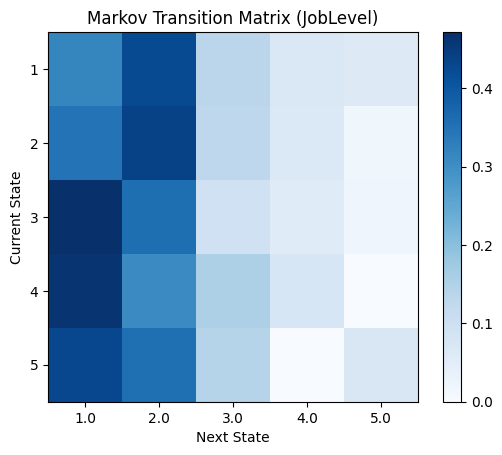

In [ ]:
plt.imshow(transition_matrix, cmap='Blues')
plt.xticks(range(len(transition_matrix.columns)), transition_matrix.columns)
plt.yticks(range(len(transition_matrix.index)), transition_matrix.index)
plt.title("Markov Transition Matrix (JobLevel)")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.colorbar()
plt.show()